RNN-With Additional Features Engineered from the datasets

In [ ]:
!pip install opendatasets --quiet

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/competitions/ventilator-pressure-prediction/data?select=train.csv")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sulovebhattarai
Your Kaggle Key: ··········


100%|██████████| 223M/223M [00:00<00:00, 961MB/s] 



Extracting archive ./ventilator-pressure-prediction/ventilator-pressure-prediction.zip to ./ventilator-pressure-prediction


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Load train and test datasets

In [ ]:
train_df = pd.read_csv("/content/ventilator-pressure-prediction/train.csv")
test_df= pd.read_csv("/content/ventilator-pressure-prediction/test.csv")

###### Additional Features:
- **u_in_cumsum**: sum of air input to the lung
- **u_in_lag1**: input flow just one step before
- **u_out_lag1**: output valve (open or close) just one step before
- **u_in_lag2**: input flow just two step before
- **u_out_lag2**: output flow (open or close) just two step before
- **u_in_lag_back1**: looks one step ahead inside same breath
- **u_out_lag_back1**: output valve (open or close) one step in future
- **u_in_lag_back2**: looks two step ahead inside same breath
- **u_out_lag_back2**: output valve (open or close) two step in future

In [ ]:
def add_breath_features(df):


    df['u_in_cumsum'] = df.groupby('breath_id')['u_in'].cumsum()


    df['u_in_lag1'] = df.groupby('breath_id')['u_in'].shift(1)
    df['u_out_lag1'] = df.groupby('breath_id')['u_out'].shift(1)

    df['u_in_lag2'] = df.groupby('breath_id')['u_in'].shift(2)
    df['u_out_lag2'] = df.groupby('breath_id')['u_out'].shift(2)


    df['u_in_lag_back1'] = df.groupby('breath_id')['u_in'].shift(-1)
    df['u_out_lag_back1'] = df.groupby('breath_id')['u_out'].shift(-1)

    df['u_in_lag_back2'] = df.groupby('breath_id')['u_in'].shift(-2)
    df['u_out_lag_back2'] = df.groupby('breath_id')['u_out'].shift(-2)

    return df


In [ ]:
train_df = add_breath_features(train_df)
test_df  = add_breath_features(test_df)


In [ ]:
train_df = pd.get_dummies(train_df, columns=["R","C"])
test_df  = pd.get_dummies(test_df,  columns=["R","C"])

In [ ]:
train_df = train_df.fillna(0)
test_df  = test_df.fillna(0)

In [ ]:
numeric_cols = [
    "time_step", "u_in",
    "u_in_cumsum",
    "u_in_lag1", "u_out_lag1",
    "u_in_lag2", "u_out_lag2",
    "u_in_lag_back1", "u_out_lag_back1",
    "u_in_lag_back2", "u_out_lag_back2"
]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Data Standarization

In [ ]:
scaler = StandardScaler()
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_df[numeric_cols]  = scaler.transform(test_df[numeric_cols])


In [ ]:
feature_cols = [c for c in train_df.columns if c not in ["id","pressure","breath_id"]]

Grouping of each breath into a sequence and converting to numpy array

In [ ]:
X = train_df.groupby("breath_id")[feature_cols].apply(
        lambda x: x.to_numpy(dtype=np.float32)
    ).to_list()
y = train_df.groupby("breath_id")["pressure"].apply(
        lambda x: x.to_numpy(dtype=np.float32)
    ).to_list()
X_test = test_df.groupby("breath_id")[feature_cols].apply(
            lambda x: x.to_numpy(dtype=np.float32)
        ).to_list()


X = np.array(X)
y = np.array(y)
X_test = np.array(X_test)

Dividing train datasets into two parts.
- **Training**: 90 %
- **Validation**: 10%

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)


Dataset class to communicate with Data loader

In [ ]:
class VentilatorDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]


train_loader = DataLoader(VentilatorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(VentilatorDataset(X_val,   y_val),   batch_size=64)
test_loader  = DataLoader(VentilatorDataset(X_test), batch_size=64)

LSTM

In [ ]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out).squeeze(-1)
        return out


input_size = len(feature_cols)
criterion = nn.L1Loss()

Random choice of the hyperparameters to tune from

In [ ]:
def sample_params():
    return {
        "hidden_size": random.choice([64, 128, 192]),
        "num_layers": random.choice([1, 2, 3]),
        "dropout": random.uniform(0.0, 0.4),
        "lr": 10 ** random.uniform(-4, -2)   # log-uniform LR
    }


In [ ]:
N_TRIALS = 10
EPOCHS = 8

best_val_mae = float("inf")
best_params = None
best_state = None
results = []

In [ ]:
import random

Trials to get the best hyperparameter, selecting the the one that gets low validation MAE

In [ ]:
for trial in range(N_TRIALS):
    print(f"\nRandom Trial {trial+1}/{N_TRIALS} ")
    params = sample_params()
    hs, nl, dp, lr = params["hidden_size"], params["num_layers"], params["dropout"], params["lr"]
    print("Sampled Params:", params)

    # Build model
    model = SimpleLSTM(input_size, hs, nl, dp).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min")

    train_hist = []
    val_hist = []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)

            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_hist.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item()

        val_loss /= len(val_loader)
        val_hist.append(val_loss)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{EPOCHS} | Train MAE={train_loss:.5f}, Val MAE={val_loss:.5f}")

    results.append((val_loss, params, train_hist, val_hist))

    if val_loss < best_val_mae:
        best_val_mae = val_loss
        best_params = params
        best_state = model.state_dict().copy()
        print("New BEST model found!")



Random Trial 1/10 
Sampled Params: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.3658473555497802, 'lr': 0.0006163558563420995}
Epoch 1/8 | Train MAE=3.53597, Val MAE=1.43094
Epoch 2/8 | Train MAE=1.16892, Val MAE=1.10893
Epoch 3/8 | Train MAE=0.94824, Val MAE=0.85419
Epoch 4/8 | Train MAE=0.86860, Val MAE=0.91929
Epoch 5/8 | Train MAE=0.82589, Val MAE=0.74514
Epoch 6/8 | Train MAE=0.79236, Val MAE=0.73204
Epoch 7/8 | Train MAE=0.76594, Val MAE=0.73175
Epoch 8/8 | Train MAE=0.74439, Val MAE=0.71721
New BEST model found!

Random Trial 2/10 
Sampled Params: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.2723732284993609, 'lr': 0.0008639859676156875}
Epoch 1/8 | Train MAE=3.20944, Val MAE=1.12842
Epoch 2/8 | Train MAE=0.99762, Val MAE=0.94622
Epoch 3/8 | Train MAE=0.85060, Val MAE=0.75889
Epoch 4/8 | Train MAE=0.79240, Val MAE=0.71960
Epoch 5/8 | Train MAE=0.75511, Val MAE=0.70199
Epoch 6/8 | Train MAE=0.72900, Val MAE=0.66459
Epoch 7/8 | Train MAE=0.70959, Val MAE=0.65745
Epoch 8

In [ ]:
print("\nBest MAE:", best_val_mae)
print("Best Params:", best_params)


Best MAE: 0.5784946836657443
Best Params: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.22046672333053202, 'lr': 0.0008865946441062367}


Training with the Best Hyperparameters
- Training till 450 epochs
- Adam opitmizer

In [ ]:
hs, nl, dp, lr = best_params.values()

final_model = SimpleLSTM(input_size, hs, nl, dp).to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min")

FINAL_EPOCHS = 450
final_train_hist = []
final_val_hist = []

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = final_model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    final_train_hist.append(train_loss)

    final_model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            val_loss += criterion(final_model(Xb), yb).item()

    val_loss /= len(val_loader)
    final_val_hist.append(val_loss)

    scheduler.step(val_loss)

    print(f"[FINAL] Epoch {epoch+1}/{FINAL_EPOCHS} | Train MAE={train_loss:.5f}, Val MAE={val_loss:.5f}")

[FINAL] Epoch 1/450 | Train MAE=2.05469, Val MAE=1.00376
[FINAL] Epoch 2/450 | Train MAE=0.85779, Val MAE=0.79707
[FINAL] Epoch 3/450 | Train MAE=0.76531, Val MAE=0.94793
[FINAL] Epoch 4/450 | Train MAE=0.71324, Val MAE=0.64894
[FINAL] Epoch 5/450 | Train MAE=0.67287, Val MAE=0.66262
[FINAL] Epoch 6/450 | Train MAE=0.64688, Val MAE=0.60141
[FINAL] Epoch 7/450 | Train MAE=0.62047, Val MAE=0.63479
[FINAL] Epoch 8/450 | Train MAE=0.60472, Val MAE=0.57880
[FINAL] Epoch 9/450 | Train MAE=0.58720, Val MAE=0.56294
[FINAL] Epoch 10/450 | Train MAE=0.57697, Val MAE=0.57204
[FINAL] Epoch 11/450 | Train MAE=0.56283, Val MAE=0.59442
[FINAL] Epoch 12/450 | Train MAE=0.55227, Val MAE=0.67367
[FINAL] Epoch 13/450 | Train MAE=0.55186, Val MAE=0.50779
[FINAL] Epoch 14/450 | Train MAE=0.53275, Val MAE=0.51594
[FINAL] Epoch 15/450 | Train MAE=0.52502, Val MAE=0.58575
[FINAL] Epoch 16/450 | Train MAE=0.51820, Val MAE=0.50695
[FINAL] Epoch 17/450 | Train MAE=0.50567, Val MAE=0.48655
[FINAL] Epoch 18/450 | 

Visualization of Train MAE and Val MAE

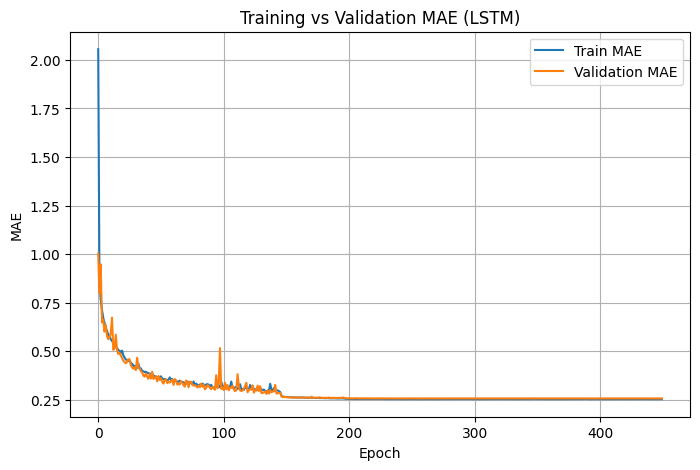

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(final_train_hist, label="Train MAE")
plt.plot(final_val_hist, label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE (LSTM)")
plt.grid(True)
plt.legend()
plt.show()

Testing of Trained LSTM on test data. <br>

-Collection of prediction

In [ ]:
preds = []
final_model.eval()

with torch.no_grad():
    for Xb in test_loader:
        Xb = Xb.to(device)
        pred = final_model(Xb)
        preds.append(pred.cpu().numpy())

preds = np.concatenate(preds).reshape(-1)
print("Test predictions shape:", preds.shape)

Test predictions shape: (4024000,)


Kaggle Submission requires the predictions to be in .csv format. <br>
With two columns **ID** and **prediction** columns

In [ ]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "pressure": preds
})

submission.to_csv("LSTM_submission_differentfeatures.csv", index=False)
print("Saved submission.csv")
submission.head()

Saved submission.csv


,id,pressure
0,1,6.110902
1,2,5.748463
2,3,6.877120
3,4,7.412261
4,5,8.786637


In [ ]:
from google.colab import files

# Download a single file
files.download('LSTM_submission_differentfeatures.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>